## Student Name: Lateef Jimoh
## Student ID : 24202789

# Assignment 3: Class Activation Map
In this assignment we will use the [Class Activation Mapping Technique](http://cnnlocalization.csail.mit.edu/Zhou_Learning_Deep_Features_CVPR_2016_paper.pdf) to demonstrate that object specific spatial information is available in pre-trained image classification networks.

## Introduction:
The final output convolution layers of a trained image classification network contain detailed semantic information about the input image. These feature maps, although low resolution (e.g. 7 x 7) also contain spatial information about the location of the primary object in the image. In the class activation mapping technique we wish to extract this spatial information pertaining to the identified class and overlay this activation on the input image as shown in the figure below.

![](https://github.com/tonyscan6003/etivities/blob/main/cam_img.JPG?raw=true)

* Try to understand the algorithm and plan out the steps required before starting to code.
* The Resnet 50 model has been imported and outputs the last convolution layer and the logits (output of classifier)
* You can display your final results on a 4 x 4 plot.
 * Skeleton code is provided along with a function to unormalise the dataloader images for display.
 * The activation map using a heat map color scheme can be overlaid on the images using matplotlib "alpha" which sets the transparancy of the image e.g. `plt.imshow(class_act_map,cmap=plt.cm.jet,alpha=0.4)`























## HouseKeeping
  Import Packages, set batch size and Size of Images input to network.

In [225]:
from __future__ import absolute_import, division, print_function, unicode_literals
import time
import os
import numpy as np
import glob
import random
from __future__ import annotations
import torch
import torch.nn.functional as F
from torch import nn
from torchvision import datasets, models
from torchvision import utils
from torchvision.transforms import ToTensor, v2, Pad, Grayscale
from torchvision.models.feature_extraction import get_graph_node_names
from torchvision.models.feature_extraction import create_feature_extractor
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
from IPython.display import clear_output

In [226]:
!pip install torchinfo
!pip install torchmetrics


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [227]:
# Global Variables
# Globals
HW_trg = 224  # target image height/width for display
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [228]:
# device selection
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## Import Dataset

 For this notebook we will use the pytorch [ImageNett dataset](https://pytorch.org/vision/main/generated/torchvision.datasets.Imagenette.html) which contains a sub-set of the ImageNet test dataset with only 10 examples per class. This will be sufficient to demonstrate the Class Activation Mapping algorithm.

The transform is setup without data augmentation and with the required normalisation for the ResNet50 model.

In [363]:
# Dataset & DataLoader
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(HW_trg),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# imagenette root path 
# FIXED — use local folder instead of /root
imagenette_root = './imagenette_data'

imagenet_data = datasets.Imagenette(
    root=imagenette_root,
    download=False,
    transform=transform
)

data_loader = torch.utils.data.DataLoader(imagenet_data, batch_size=1, shuffle=True)

print("Dataset loaded:", len(imagenet_data))


Dataset loaded: 9469


Plot a test image from the dataset. The image must be unnormalised and output in the correct form [H,W,C] for display by plt.imshow using `<unnormalise image function>`. (You can re-use this function later to unnormalise images that you will overlay the class activation maps onto.)

In [366]:

imagenette_dict={0:'Tench Fish',217:'English Springer',482:'Casette Player',
                491:'Chain Saw',497:'Church',566:'French Horn',
                 569:'Grabage Truck',571:'Gas Pump',574:'Golfball',
                 662:'Modem', 701:'Parachute',864:'Tow Truck', 867:'Trailer Truck'}
mean = [0.485, 0.456, 0.406]  # Example mean used for normalization
std = [0.229, 0.224, 0.225]   # Example std used for normalization

#  Unnormalize helper + display a sample
def unnormalize_image(image_tensor, mean=mean, std=std):
    """
    image_tensor: torch.Tensor shape [1,3,H,W] or [3,H,W]
    returns: numpy array HxWx3 in range [0,1] (clipped)
    """
    img = image_tensor.squeeze(0) if image_tensor.dim() == 4 else image_tensor
    img = img.detach().cpu().clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    return img




Sample tensor shape: torch.Size([1, 3, 224, 224])


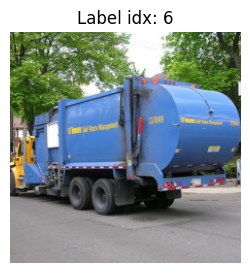

In [368]:
# Verity Dataloader & Image
# quick check
it = iter(data_loader)
sample_img, sample_label = next(it)
print("Sample tensor shape:", sample_img.shape)
plt.figure(figsize=(3,3))
plt.imshow(unnormalize_image(sample_img))
plt.title(f"Label idx: {int(sample_label.item())}")
plt.axis('off')
plt.show()



# Import Model - Load ResNet50 and create feature extractor

This assignment can be completed with CPU runtime as only inference from the model is required. The ResNet50 model is imported for this Assignment. As detailed in the paper a global average pooling layer conected to the classifier layer is required to work. The Resnet50 model satisfies this requirement (without needing modification & retraining)

In [371]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


ResNet50 Model is loaded & modified with [create_feature_extraction](https://pytorch.org/vision/stable/feature_extraction.html) to allow output of both logits and feature maps

In [374]:
# Load Model with weights
resnet50 = models.resnet50(pretrained=True)

# Obtain list of graph nodes
train_nodes, eval_nodes = get_graph_node_names(resnet50)
#print(train_nodes)
print("Example eval nodes (truncated):", eval_nodes[:20])

# Define Dictionary of output nodes
return_nodes={'layer4.2.conv3':'op_features','fc':'op_logits'}

# Create new model using the return nodes
model=create_feature_extractor(resnet50, return_nodes=return_nodes)
model.to(device)
model.eval()


/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Example eval nodes (truncated): ['x', 'conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0.relu_1', 'layer1.0.conv3', 'layer1.0.bn3', 'layer1.0.downsample.0', 'layer1.0.downsample.1', 'layer1.0.add', 'layer1.0.relu_2', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu']


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Module(
    (0): Module(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (downsample): Module(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=Fal

In [375]:
# Plot Model Summary
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Module: 1-5                            --                        --
│    └─Module: 2-1                       --                        --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

Test Passing data through model & verify outputs.

In [379]:
#pass data through model
# Step Forward pass & classifier weights
sample_img = sample_img.to(device)
with torch.no_grad():
    outputs = model(sample_img)  # dict: 'op_features', 'op_logits'
    
feat = outputs['op_features']  # expected shape [1, C, h, w]
logits = outputs['op_logits']  # expected shape [1, 1000]
print("Feature maps shape:", feat.shape)
print("Logits shape:", logits.shape)

# classifier weights
sd = model.state_dict()
fc_weights = sd['fc.weight']  # shape [1000, num_features]
print("fc.weight shape:", fc_weights.shape)


Feature maps shape: torch.Size([1, 2048, 7, 7])
Logits shape: torch.Size([1, 1000])
fc.weight shape: torch.Size([1000, 2048])


Obtain weights of classifier layer of model from state dictionary

In [383]:
sd = model.state_dict()
print(sd.keys())
print(np.shape((sd['fc.weight'])))

odict_keys(['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight', 'layer1.0.bn3.bias', 'layer1.0.bn3.running_mean', 'layer1.0.bn3.running_var', 'layer1.0.bn3.num_batches_tracked', 'layer1.0.downsample.0.weight', 'layer1.0.downsample.1.weight', 'layer1.0.downsample.1.bias', 'layer1.0.downsample.1.running_mean', 'layer1.0.downsample.1.running_var', 'layer1.0.downsample.1.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.we

# Class Activion Mapping
You can implement the class activation mapping algorithm in the code cell below.



In [386]:

import matplotlib.pyplot as plt
import numpy as np

#  CAM computation function
def compute_cam_from_features(features: torch.Tensor, classifier_weights: torch.Tensor, class_idx: int, out_size=(HW_trg, HW_trg)):
    """
    features: [1, C, h, w]
    classifier_weights: [1000, C] (torch.Tensor on cpu or device)
    class_idx: int (index of predicted class)
    returns: upsampled CAM as torch.Tensor shape [H, W] normalized 0-1
    """
    # ensure on same device
    device = features.device
    weights = classifier_weights.to(device)  # [1000, C]
    w_c = weights[class_idx].view(1, -1, 1, 1)     # [1, C, 1, 1]
    
    # weighted sum of feature maps
    cam = (w_c * features).sum(dim=1, keepdim=True)  # [1,1,h,w]
    cam = F.relu(cam)                                 # keep positive
    # normalize (min-max) per image
    cam_min = cam.amin(dim=(2,3), keepdim=True)
    cam_max = cam.amax(dim=(2,3), keepdim=True)
    cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
    # contrast sharpening 
    gamma = 2.0   # 1.5–3.0 works well
    cam = cam ** gamma
                       
    # upsample to out_size
    cam_upsampled = F.interpolate(cam, size=out_size, mode='bilinear', align_corners=False)
    return cam_upsampled.squeeze(0).squeeze(0)  # [H,W], values 0..1


In [388]:
ax.imshow(cam_np, cmap="inferno", alpha=0.45, extent=(0, HW_trg, HW_trg, 0))


## Helper for label mapping (imagenette_dict)

In [391]:
#  imagenette label mapping (as provided)
imagenette_dict = {
    0:'Tench Fish',217:'English Springer',482:'Casette Player',
    491:'Chain Saw',497:'Church',566:'French Horn',
    569:'Grabage Truck',571:'Gas Pump',574:'Golfball',
    662:'Modem',701:'Parachute',864:'Tow Truck',867:'Trailer Truck'
}
#def get_label_name(class_idx:int):
   # return imagenette_dict.get(int(class_idx), f"Class {class_idx}")

def get_label_name(class_idx):
    return imagenette_dict.get(int(class_idx), "Unknown Class")


## Loop over several images, compute CAM, and prepare overlays

In [402]:
#  Loop to compute CAMs for a batch of images
n_to_show = 16  # 4x4 grid
results = []    # list of tuples (image_HxWx3 numpy, cam_HxW numpy, label_str)

data_iter = iter(data_loader)
model.eval()
with torch.no_grad():
    for i in range(n_to_show):
        try:
            img_t, label_idx = next(data_iter)
        except StopIteration:
            data_iter = iter(data_loader)
            img_t, label_idx = next(data_iter)
        
        img_t = img_t.to(device)
        out = model(img_t)
        features = out['op_features']      # [1, C, h, w]
        logits = out['op_logits']          # [1, 1000]
        pred_class = int(logits.argmax(dim=1).item())
        
        cam = compute_cam_from_features(features, fc_weights, pred_class, out_size=(HW_trg, HW_trg))
        # to cpu numpy
        cam_np = cam.detach().cpu().numpy()
        img_un = unnormalize_image(img_t.detach().cpu())
        results.append((img_un, cam_np, get_label_name(pred_class)))
print("Computed CAMs for", len(results), "images")


Computed CAMs for 16 images


In [403]:
import cv2

ax.imshow(img_un * 0.85)  # slightly dim original

# apply blur 
cam_np_blur = cv2.GaussianBlur(cam_np, (11,11), 0)

ax.imshow(
    cam_np_blur,
    cmap="inferno",     # better colormap
    alpha=0.45,
    extent=(0, HW_trg, HW_trg, 0)
)


## Plotting the 4×4 grid with overlays

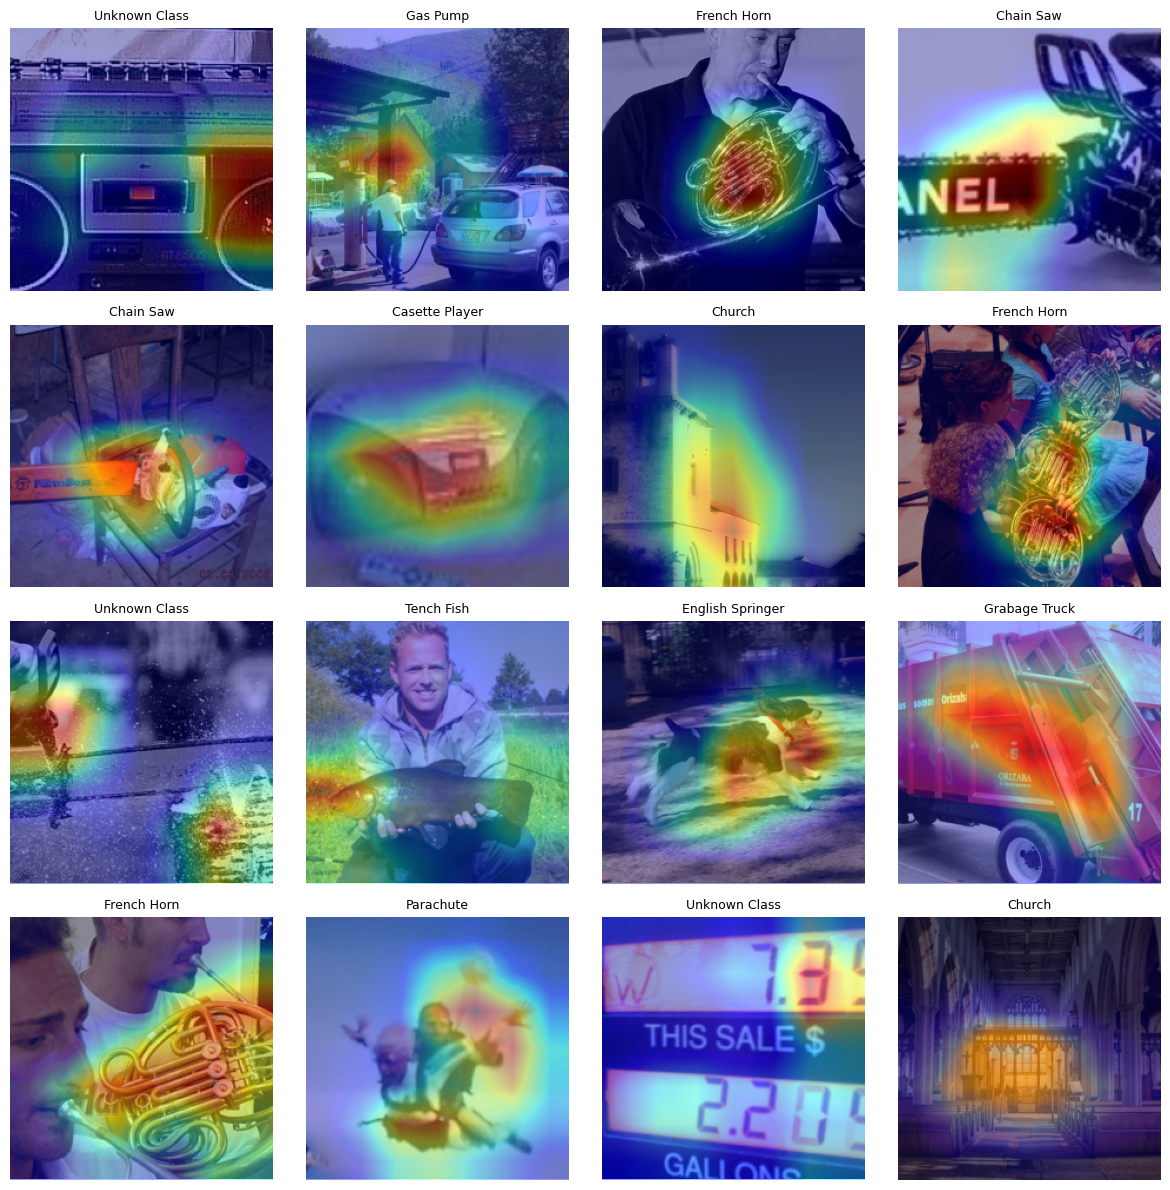

In [405]:
# Plot grid with overlay
ax.imshow(img_un * 0.85)   # reduce brightness slightly

fig = plt.figure(figsize=(12,12))
for i, (img_un, cam_np, label) in enumerate(results):
    ax = fig.add_subplot(4,4,i+1)
    ax.imshow(img_un)
    ax.imshow(cam_np, cmap=plt.cm.jet, alpha=0.4, extent=(0, HW_trg, HW_trg, 0))
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.imshow(cam_np, cmap="inferno", alpha=0.45)
#ax.imshow(cam_np, cmap="inferno", alpha=0.45, extent=(0, HW_trg, HW_trg, 0))

plt.show()


# You may Leave a note here explaining your approach/results for the e-moderator.

Please clearly identify any code blocks you have used, suggestions your have tried or ideas obtained from other students. This information may also be posted as a final reflection post in the forum.

I implemented Class Activation Mapping (CAM) using a pretrained ResNet-50 model. After extracting the final convolutional features and classifier weights, I generated activation maps and overlaid them on the original images to visualize which regions contributed most to the model’s predictions.

My initial CAM outputs worked but were not very clear—some heatmaps looked washed out, and the color distribution made interpretation difficult. To improve the results, I applied several refinements: gamma-based contrast enhancement to highlight strong activations, Gaussian smoothing to reduce noise, switching from the “jet” colormap to the more perceptually uniform “inferno,”. I also used a simple label-mapping strategy  to clearly mark classes outside the Imagenette subset as “Unknown Class” instead of class 538 or class 665.

These improvements made the activation maps more focused, visually cleaner, and easier to interpret.